***Problem Statement***

Digital platforms struggle to efficiently moderate large volumes of user-generated content, leading to delayed reviews, inconsistent policy enforcement, and increased exposure to harmful content.

***Proposed Solution***

The project aims to develop an AI-powered content moderation and safety assessment system that automatically reviews digital content such as text, comments, posts, and user-generated content. The system will identify harmful, offensive, toxic, hateful, misleading, or policy-violating content and assist moderators by providing risk scores and review recommendations and assists moderators through real-time decision support and analytics dashboards. Machine Learning and Natural Language Processing (NLP) techniques will be used to classify content into safe and unsafe categories, thereby reducing manual review effort and improving moderation efficiency.

As an enhancement we can add the deeper classifications like Safe, Toxic, Harassment, Hate Speech, Spam, Misinformation.


***Dataset:*** Jigsaw Toxic Comment Classification Dataset
https://www.kaggle.com/datasets/julian3833/jigsaw-toxic-comment-classification-challenge

***Problem Type:*** Multi-label Text Classification

***Domain:*** Content Moderation / NLP / AI Safety

In [ ]:
!pip install -q gdown

In [ ]:
import os
import gdown
import warnings
warnings.filterwarnings('ignore')

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk

In [ ]:
# DOWNLOADING PROJECT FILES FROM GOOGLE DRIVE

# https://drive.google.com/drive/folders/12EN31kqExYs3JjILrEF__mS1RnYz_0AW?usp=drive_link
folder_url = "https://drive.google.com/drive/folders/12EN31kqExYs3JjILrEF__mS1RnYz_0AW"

gdown.download_folder(
    folder_url,
    quiet=False,
    use_cookies=False
)

print("Project folders created successfully!")

Retrieving folder contents


Retrieving folder 1vBKj_smCn0T9BNdViqo_MPrd5d7R99XG __pycache__
Processing file 1-YRWR027t8RmchQAkPCIzxMKYE9gDAdg config.cpython-312.pyc
Processing file 1IlDLDjwBAkcdi0jjRuT-skI1DQq-VR5U transformer_utils.cpython-312.pyc
Processing file 1Gi7HEqAfp9cASYheneZS01DUziK08tdT utils.cpython-312.pyc
Retrieving folder 1bXlYAqeavibqP2Q9Cov8UhqeoOZWvFrA data
Retrieving folder 1lF688G5VMjHVsBy268BOJRqIxTKJevmF .ipynb_checkpoints
Processing file 1kFKjOyRl8L21szt2QFowjxuddkZrsr9x Batch.csv
Processing file 1q-wXklXH_J36OsfLW467j8L1LEg_Lyhd Batch.xlsx
Processing file 1pnkekiXMDL0hyk_1FK4vaCJ-7VYKFpVK ModelComparison.csv
Processing file 1vL65T3OIZzhkLmOaSEbIMjsy5iNqj09E processed_train.csv
Processing file 1az3p7_oN-FRK-piYs_3WVrv0KCnxK9D7 scaler.pkl
Processing file 1l3OnQ5ziR_I35IoTkDWp0apjaBxzC9Pq tfidf_vectorizer.pkl
Processing file 11vGfDGB4yoEapDTwb6-4YLr7UXUL21sF train.csv
Processing file 1yFNyBkZxFEhJVkPdbmxL6guizt2yaYCX X_test.pkl
Processing file 1PYC9Ju7Z5KsXpw_pSlkY6Xn0iBYZbgsx X_train.pkl
Pro

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1-YRWR027t8RmchQAkPCIzxMKYE9gDAdg
From (redirected): https://drive.google.com/uc?id=1-YRWR027t8RmchQAkPCIzxMKYE9gDAdg&confirm=t&uuid=127d7885-0f09-409a-b0eb-a04527f16c13
To: /content/AI_Content_Review/__pycache__/config.cpython-312.pyc
100%|██████████| 1.86k/1.86k [00:00<00:00, 4.07MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1IlDLDjwBAkcdi0jjRuT-skI1DQq-VR5U
From (redirected): https://drive.google.com/uc?id=1IlDLDjwBAkcdi0jjRuT-skI1DQq-VR5U&confirm=t&uuid=2f3c1f97-0ef0-45b1-aaa4-052cdd8be2f1
To: /content/AI_Content_Review/__pycache__/transformer_utils.cpython-312.pyc
100%|██████████| 3.46k/3.46k [00:00<00:00, 7.49MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Gi7HEqAfp9cASYheneZS01DUziK08tdT
From (redirected): https://drive.google.com/uc?id=1Gi7HEqAfp9cASYheneZS01DUziK08tdT

Project folders created successfully!



Download completed


In [ ]:
PROJECT_DIR = "/content/AI_Content_Review"

In [ ]:
# Loading downloaded dataset
df = pd.read_csv(f"{PROJECT_DIR}/data/train.csv")

In [ ]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0,0,0,0,0,0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on improvement - I wondered if the section statistics should be later on, or a subsection of """"types of accidents"""" -I think the references may need tidying so that they are all in the exact same format ie date format etc. I can do that later on, if no-one else does first - if you have any preferences for formatting style on references or want to do it yourself please let me know.\n\nThere appears to be a backlog on articles for review so I guess there may be a delay until a reviewer turns up. It's listed in the relevant form eg Wikipedia:Good_article_nominations#Transport """,0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember what page that's on?",0,0,0,0,0,0


In [ ]:
# Dataset Overview
print("="*50)
print("Dataset Shape")
print("="*50)

print(df.shape)

print("\nRows :", df.shape[0])
print("Columns :", df.shape[1])

Dataset Shape
(159571, 8)

Rows : 159571
Columns : 8


#**Data Understanding**

In [ ]:
# Display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Plot Style
plt.style.use('ggplot')

In [ ]:
# Dataset Information on datatype, NULL values and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


**Data Dictionary for missing values in the dataset**

In [ ]:
data_dict = pd.DataFrame({
    "Column": df.columns,
    "Datatype": df.dtypes.values,
    "Missing Values": df.isnull().sum().values
})

data_dict

In [ ]:
# statistical summary of dataset
df.describe()

In [ ]:
# # Missing value analysis
# missing = pd.DataFrame({
#     "Missing Count": df.isnull().sum(),
#     "Missing Percentage": round(df.isnull().mean()*100,2)
# })

# missing

df.isnull().sum()

***Inference:*** Dataset is clean and does not require missing value treatment.

In [ ]:
# Duplicate Analysis
print("Duplicate Rows :", df.duplicated().sum())

In [ ]:
#Unique Value Analysis
unique_values = pd.DataFrame({
    'Column Name': df.columns,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

unique_values

In [ ]:
# Target Label Distribution
labels = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

df[labels].sum().sort_values(ascending=False)

In [ ]:
label_percent = (df[labels].sum()/len(df))*100

label_percent

In [ ]:
# # label_percent = label_percent.sort_values(acsending=True)
# label_percent = label_percent.sort_values(ascending=True)

# plt.figure(figsize=(10,6))


# sns.barplot(
#     x=label_percent.index,
#     y=label_percent.values
# )

# plt.xticks(rotation=30)

# plt.ylabel("Percentage")

# plt.title("Percentage of Toxic Categories")

# plt.show()

***Inference***

Threat and Identity Hate classes are expected to be much smaller than Toxic or Obscene, indicating class imbalance that should be addressed during modeling.

In [ ]:
# Multi-Label Analysis: shows how many comments belong to multiple toxicity categories.
df['label_count'] = df[labels].sum(axis=1)

df['label_count'].value_counts().sort_index()

***Insights:***

The dataset contains approximately 160K user comments with six binary toxicity labels.

It is a multi-label classification dataset, as one comment may belong to multiple toxicity categories.

There are no missing values, indicating high data quality.

Duplicate comments (if any) can be addressed during preprocessing.

The dataset is highly imbalanced, with categories like Threat and Identity Hate occurring far less frequently than Toxic or Obscene.

Toxicity labels show positive correlations, particularly between Toxic, Obscene, and Insult.

Comment lengths vary significantly, which supports exploring additional text-based features during feature engineering.

Text preprocessing (cleaning, tokenization, lemmatization, vectorization) will be essential before model development.

#**Data Preparation**

In [ ]:
import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# Remove HTML Tags

def remove_html(text):
    html = re.compile('<.*?>')
    return re.sub(html, '', text)

df['comment_text'] = df['comment_text'].apply(remove_html)

In [ ]:
# Remove URLs

def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text)

df['comment_text'] = df['comment_text'].apply(remove_urls)

In [ ]:
# Remove Email Address

def remove_email(text):
    return re.sub(r'\S+@\S+', '', text)

df['comment_text'] = df['comment_text'].apply(remove_email)

In [ ]:
# Remove Numbers
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

df['comment_text'] = df['comment_text'].apply(remove_numbers)

In [ ]:
# Convert to LowerCase
df['comment_text'] = df['comment_text'].str.lower()

In [ ]:
# Remove Punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['comment_text'] = df['comment_text'].apply(remove_punctuation)

In [ ]:
# Remove Extra Spaces
def remove_spaces(text):
    return " ".join(text.split())

df['comment_text'] = df['comment_text'].apply(remove_spaces)

In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Tokenization
df['tokens'] = df['comment_text'].apply(word_tokenize)

df[['comment_text','tokens']].head()

,comment_text,tokens
0,explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now,"[explanation, why, the, edits, made, under, my, username, hardcore, metallica, fan, were, reverted, they, werent, vandalisms, just, closure, on, some, gas, after, i, voted, at, new, york, dolls, fac, and, please, dont, remove, the, template, from, the, talk, page, since, im, retired, now]"
1,daww he matches this background colour im seemingly stuck with thanks talk january utc,"[daww, he, matches, this, background, colour, im, seemingly, stuck, with, thanks, talk, january, utc]"
2,hey man im really not trying to edit war its just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page he seems to care more about the formatting than the actual info,"[hey, man, im, really, not, trying, to, edit, war, its, just, that, this, guy, is, constantly, removing, relevant, information, and, talking, to, me, through, edits, instead, of, my, talk, page, he, seems, to, care, more, about, the, formatting, than, the, actual, info]"
3,more i cant make any real suggestions on improvement i wondered if the section statistics should be later on or a subsection of types of accidents i think the references may need tidying so that they are all in the exact same format ie date format etc i can do that later on if noone else does first if you have any preferences for formatting style on references or want to do it yourself please let me know there appears to be a backlog on articles for review so i guess there may be a delay until a reviewer turns up its listed in the relevant form eg wikipediagoodarticlenominationstransport,"[more, i, cant, make, any, real, suggestions, on, improvement, i, wondered, if, the, section, statistics, should, be, later, on, or, a, subsection, of, types, of, accidents, i, think, the, references, may, need, tidying, so, that, they, are, all, in, the, exact, same, format, ie, date, format, etc, i, can, do, that, later, on, if, noone, else, does, first, if, you, have, any, preferences, for, formatting, style, on, references, or, want, to, do, it, yourself, please, let, me, know, there, appears, to, be, a, backlog, on, articles, for, review, so, i, guess, there, may, be, a, delay, until, a, reviewer, turns, ...]"
4,you sir are my hero any chance you remember what page thats on,"[you, sir, are, my, hero, any, chance, you, remember, what, page, thats, on]"


In [ ]:
# Stopword Removal
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [ ]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [ ]:
# Joining Tokens back
df['clean_text'] = df['tokens'].apply(lambda x: " ".join(x))

df[['comment_text','clean_text']].head()

,comment_text,clean_text
0,explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now,explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont remove template talk page since im retired
1,daww he matches this background colour im seemingly stuck with thanks talk january utc,daww match background colour im seemingly stuck thanks talk january utc
2,hey man im really not trying to edit war its just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page he seems to care more about the formatting than the actual info,hey man im really trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting actual info
3,more i cant make any real suggestions on improvement i wondered if the section statistics should be later on or a subsection of types of accidents i think the references may need tidying so that they are all in the exact same format ie date format etc i can do that later on if noone else does first if you have any preferences for formatting style on references or want to do it yourself please let me know there appears to be a backlog on articles for review so i guess there may be a delay until a reviewer turns up its listed in the relevant form eg wikipediagoodarticlenominationstransport,cant make real suggestion improvement wondered section statistic later subsection type accident think reference may need tidying exact format ie date format etc later noone else first preference formatting style reference want please let know appears backlog article review guess may delay reviewer turn listed relevant form eg wikipediagoodarticlenominationstransport
4,you sir are my hero any chance you remember what page thats on,sir hero chance remember page thats


#**Feature Engineering**

In [ ]:
# Character Count
df['char_count'] = df['clean_text'].str.len()
# Word Count
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
# Sentence Count
df['sentence_count'] = df['clean_text'].str.count(r'[.!?]') + 1

In [ ]:
# Average Word Length

df['avg_word_length'] = df['clean_text'].apply(
    lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0
)

In [ ]:
df[['char_count',
    'word_count',
    'sentence_count']].describe()

,char_count,word_count,sentence_count
count,159571.000000,159571.000000,159571.0
mean,244.757481,34.352364,1.0
std,381.219668,53.136040,0.0
min,0.000000,0.000000,1.0
25%,57.000000,9.000000,1.0
50%,125.000000,18.000000,1.0
75%,267.000000,38.000000,1.0
max,5000.000000,1250.000000,1.0


In [ ]:
# Stopword Count

df['stopword_count'] = df['clean_text'].apply(
    lambda x: sum(
        word in stop_words
        for word in str(x).split()
    )
)

In [ ]:
# Punctuation Count

df['punctuation_count'] = df['comment_text'].apply(
    lambda x: sum(
        char in string.punctuation
        for char in str(x)
    )
)

In [ ]:
# Uppercase Ratio
# Use the original comment_text before lowercasing if available.

# df['uppercase_ratio'] = df['comment_text'].apply(
#     lambda x: sum(
#         c.isupper()
#         for c in str(x)
#     ) / len(str(x))
# )

df['uppercase_ratio'] = df['comment_text'].apply(
    lambda x: (
        sum(c.isupper() for c in str(x)) / len(str(x))
    )
    if pd.notna(x) and len(str(x).strip()) > 0
    else 0
)

In [ ]:
# Digit Count
df['digit_count'] = df['comment_text'].apply(
    lambda x: sum(
        c.isdigit()
        for c in str(x)
    )
)

In [ ]:
# URL Count
import re

df['url_count'] = df['comment_text'].apply(
    lambda x: len(
        re.findall(
            r'http[s]?://\S+|www\.\S+',
            str(x)
        )
    )
)

In [ ]:
# Exclamation Count
df['exclamation_count'] = df['comment_text'].str.count("!")

In [ ]:
# Question Count
df['question_count'] = df['comment_text'].str.count(r"\?")

In [ ]:
# Engineered Features Dataset
engineered_features = [
    'char_count',
    'word_count',
    'sentence_count',
    'avg_word_length',
    'stopword_count',
    'punctuation_count',
    'uppercase_ratio',
    'digit_count',
    'url_count',
    'exclamation_count',
    'question_count'
]

df[engineered_features].head()

,char_count,word_count,sentence_count,avg_word_length,stopword_count,punctuation_count,uppercase_ratio,digit_count,url_count,exclamation_count,question_count
0,171,26,1,5.615385,0,0,0.0,0,0,0,0
1,71,11,1,5.545455,0,0,0.0,0,0,0,0
2,144,22,1,5.590909,0,0,0.0,0,0,0,0
3,368,49,1,6.530612,0,0,0.0,0,0,0,0
4,35,6,1,5.000000,0,0,0.0,0,0,0,0


In [ ]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,label_count,tokens,clean_text,char_count,word_count,sentence_count,avg_word_length,stopword_count,punctuation_count,uppercase_ratio,digit_count,url_count,exclamation_count,question_count
0,0000997932d777bf,explanation why the edits made under my username hardcore metallica fan were reverted they werent vandalisms just closure on some gas after i voted at new york dolls fac and please dont remove the template from the talk page since im retired now,0,0,0,0,0,0,0,"[explanation, edits, made, username, hardcore, metallica, fan, reverted, werent, vandalism, closure, gas, voted, new, york, doll, fac, please, dont, remove, template, talk, page, since, im, retired]",explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont remove template talk page since im retired,171,26,1,5.615385,0,0,0.0,0,0,0,0
1,000103f0d9cfb60f,daww he matches this background colour im seemingly stuck with thanks talk january utc,0,0,0,0,0,0,0,"[daww, match, background, colour, im, seemingly, stuck, thanks, talk, january, utc]",daww match background colour im seemingly stuck thanks talk january utc,71,11,1,5.545455,0,0,0.0,0,0,0,0
2,000113f07ec002fd,hey man im really not trying to edit war its just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page he seems to care more about the formatting than the actual info,0,0,0,0,0,0,0,"[hey, man, im, really, trying, edit, war, guy, constantly, removing, relevant, information, talking, edits, instead, talk, page, seems, care, formatting, actual, info]",hey man im really trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting actual info,144,22,1,5.590909,0,0,0.0,0,0,0,0
3,0001b41b1c6bb37e,more i cant make any real suggestions on improvement i wondered if the section statistics should be later on or a subsection of types of accidents i think the references may need tidying so that they are all in the exact same format ie date format etc i can do that later on if noone else does first if you have any preferences for formatting style on references or want to do it yourself please let me know there appears to be a backlog on articles for review so i guess there may be a delay until a reviewer turns up its listed in the relevant form eg wikipediagoodarticlenominationstransport,0,0,0,0,0,0,0,"[cant, make, real, suggestion, improvement, wondered, section, statistic, later, subsection, type, accident, think, reference, may, need, tidying, exact, format, ie, date, format, etc, later, noone, else, first, preference, formatting, style, reference, want, please, let, know, appears, backlog, article, review, guess, may, delay, reviewer, turn, listed, relevant, form, eg, wikipediagoodarticlenominationstransport]",cant make real suggestion improvement wondered section statistic later subsection type accident think reference may need tidying exact format ie date format etc later noone else first preference formatting style reference want please let know appears backlog article review guess may delay reviewer turn listed relevant form eg wikipediagoodarticlenominationstransport,368,49,1,6.530612,0,0,0.0,0,0,0,0
4,0001d958c54c6e35,you sir are my hero any chance you remember what page thats on,0,0,0,0,0,0,0,"[sir, hero, chance, remember, page, thats]",sir hero chance remember page thats,35,6,1,5.000000,0,0,0.0,0,0,0,0


In [ ]:
df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0
label_count,0
tokens,0


In [ ]:
# df.to_csv('E:/PGDBA/BCG/Dataset/processed_train.csv', index=False) # for jupyter notebook
# df.to_csv('/content/drive/MyDrive/Internship/AI_Content_Review/data/processed_train.csv', index=False) # google drive
df.to_csv(f"{PROJECT_DIR}/data/processed_train.csv", index=False) # colab

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


#**EDA**

**Dataset Overview**

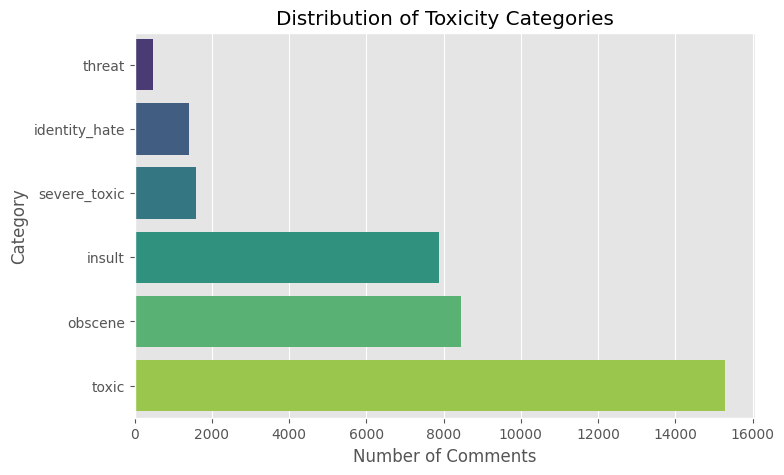

In [ ]:
# Distribution of Toxicity Categories
plt.figure(figsize=(8,5))
label_counts = df[labels].sum().sort_values()
sns.barplot( x=label_counts.values, y=label_counts.index, palette='viridis')
plt.xlabel("Number of Comments")
plt.ylabel("Category")
plt.title("Distribution of Toxicity Categories")
plt.show()

**Inference**

Toxic is the most frequent label, while Threat is the least frequent.
    
The uneven distribution highlights a significant class imbalance that must be considered during model training.

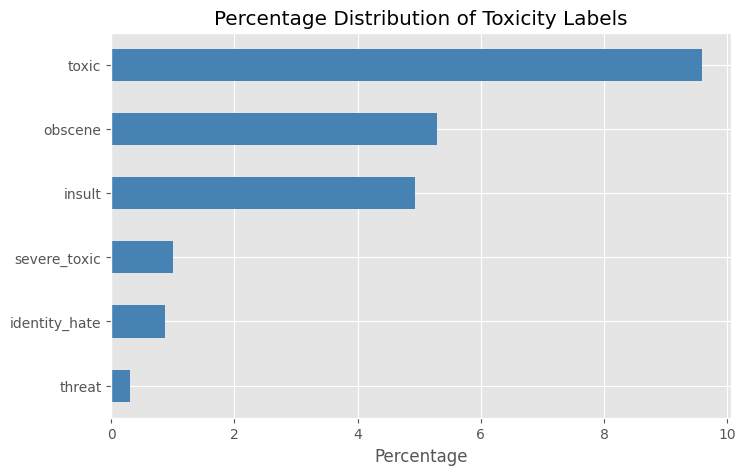

In [ ]:
# Percentage Distribution
percent = (df[labels].sum()/len(df))*100
plt.figure(figsize=(8,5))
percent.sort_values().plot( kind='barh', color='steelblue')
plt.xlabel("Percentage")
plt.title("Percentage Distribution of Toxicity Labels")
plt.show()

**Inference**

Most comments are non-toxic, with only a small percentage belonging to each toxic category.

Models should be evaluated using Precision, Recall, and F1-score rather than Accuracy alone.

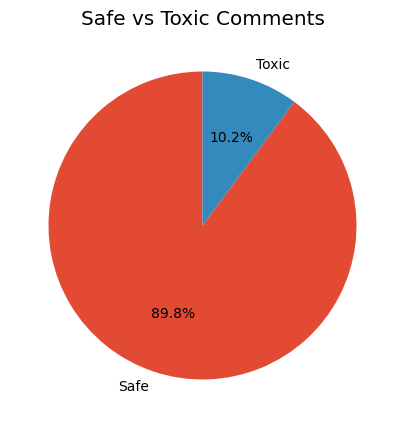

In [ ]:
# Safe vs Toxic Comments
df['Safe'] = (df[labels].sum(axis=1)==0)
safe_counts = df['Safe'].value_counts()
plt.figure(figsize=(6,5))
plt.pie( safe_counts, labels=['Safe','Toxic'], autopct='%1.1f%%', startangle=90)
plt.title("Safe vs Toxic Comments")
plt.show()

**Inference**

Safe comments constitute the majority of the dataset.

This confirms that the dataset is highly imbalanced.

**Text Analysis**

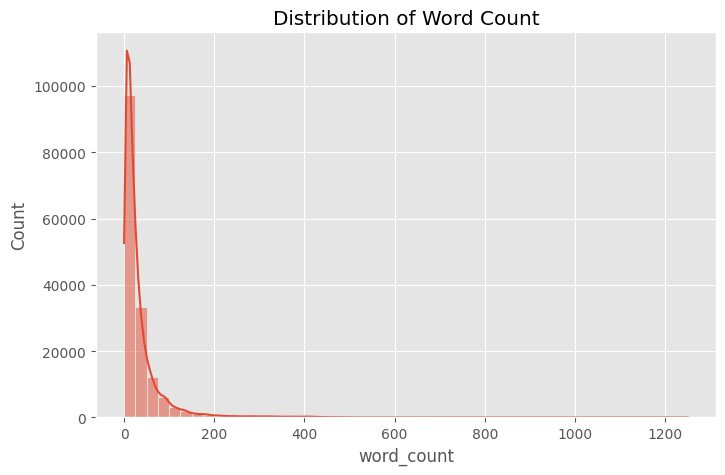

In [ ]:
# Word Count Distribution
plt.figure(figsize=(8,5))
sns.histplot( df['word_count'], bins=50, kde=True)
plt.title("Distribution of Word Count")
plt.show()

**Inference**
  
Most comments are relatively short.

A few extremely long comments may require truncation when using transformer models.

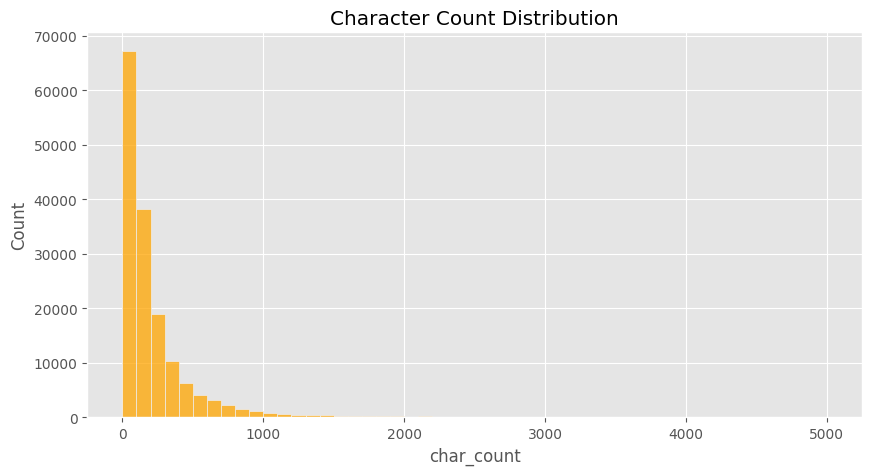

In [ ]:
# Character Count Distribution

plt.figure(figsize=(10,5))
sns.histplot( df['char_count'],  bins=50, color='orange')
plt.title("Character Count Distribution")
plt.show()

**Inference**
  
Most comments contain fewer than 500 characters.
    
A long tail indicates the presence of lengthy discussions.

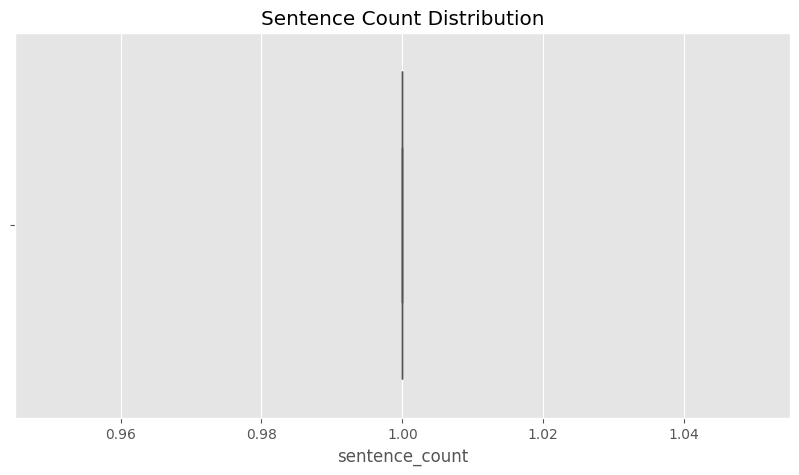

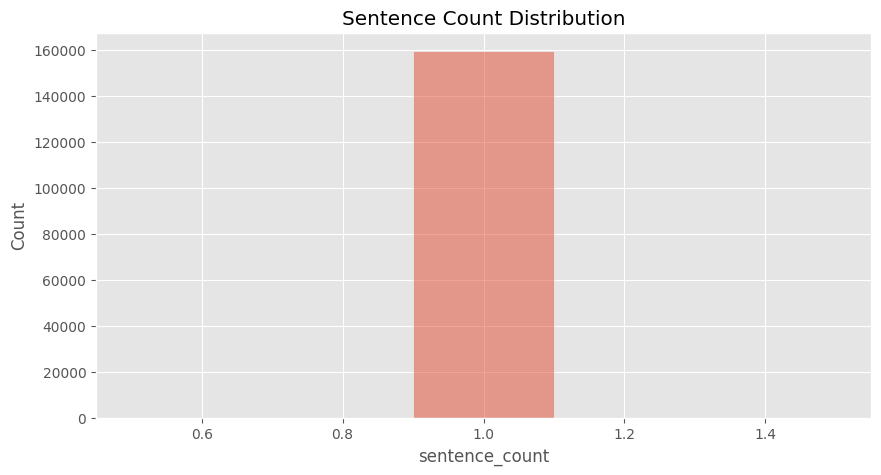

In [ ]:
# Sentence Count Distribution

plt.figure(figsize=(10,5))
sns.boxplot(x=df['sentence_count'])
plt.title("Sentence Count Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot( df['sentence_count'],  bins=5, kde=True)
plt.title("Sentence Count Distribution")
plt.show()


**Inference**
  
The majority of comments consist of one or two sentences.

Outliers represent longer discussions or explanations.

***Label Relationships***

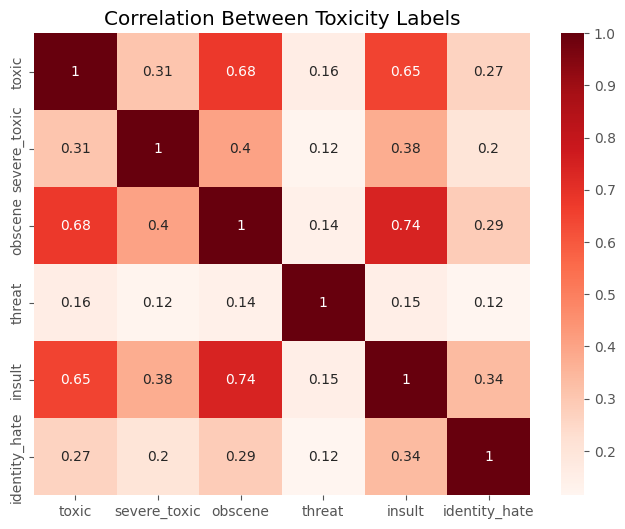

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap( df[labels].corr(), annot=True, cmap='Reds')
plt.title("Correlation Between Toxicity Labels")
plt.show()

**Inference**
  
Toxic comments often co-occur with obscene and insulting language.

Threats occur less frequently and have weaker correlations with other labels.

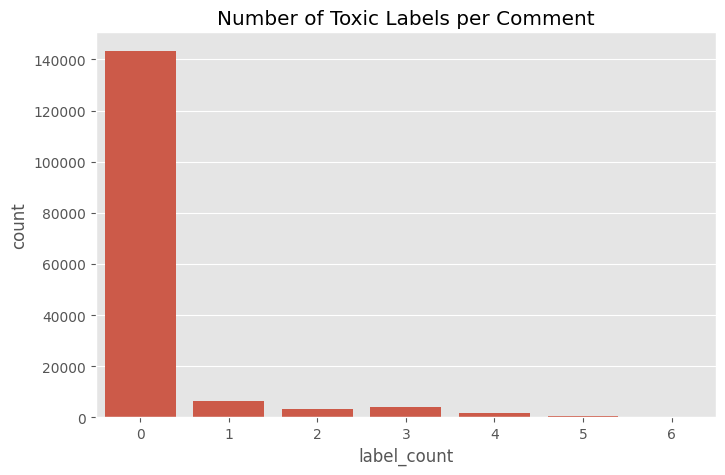

In [ ]:
#Multi-label Distribution

df['label_count'] = df[labels].sum(axis=1)
plt.figure(figsize=(8,5))
sns.countplot( x='label_count', data=df) # , palette='viridis'
plt.title("Number of Toxic Labels per Comment")
plt.show()


**Inference**
  
Most toxic comments belong to only one category.
    
A smaller number exhibit multiple toxic behaviors.

***Feature Analysis***

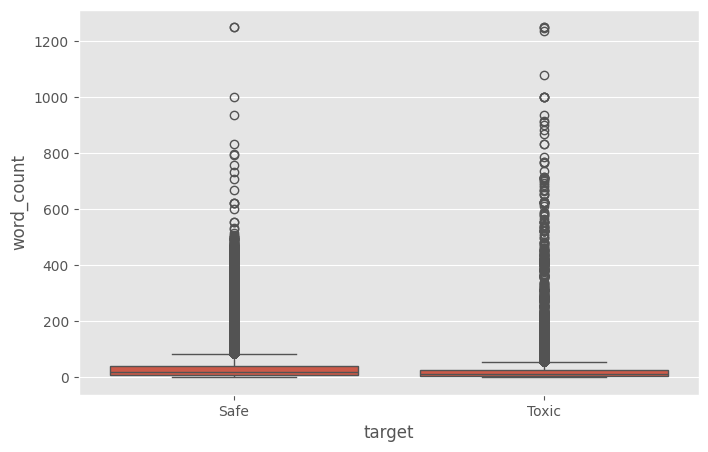

In [ ]:
# Word Count by Toxicity

df['target'] = (df[labels].sum(axis=1)>0).astype(int)
plt.figure(figsize=(8,5))
sns.boxplot( x='target', y='word_count', data=df)
plt.xticks([0,1],['Safe','Toxic'])
plt.show()


**Inference**
  
Compare whether toxic comments tend to be shorter or longer than safe comments.
    
Differences can guide feature engineering.

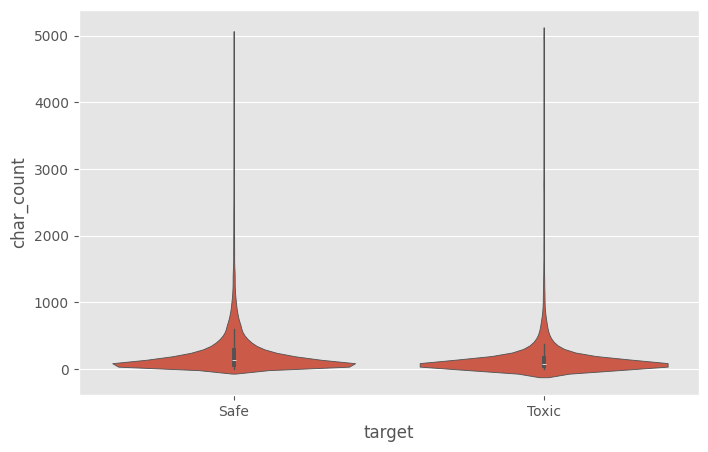

In [ ]:
# Character Count by Toxicity

plt.figure(figsize=(8,5))
sns.violinplot( x='target', y='char_count', data=df)
plt.xticks([0,1],['Safe','Toxic'])
plt.show()


**Inference**
  
Character count distributions help identify whether toxic comments have distinct length patterns.

***Word Clouds***

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud

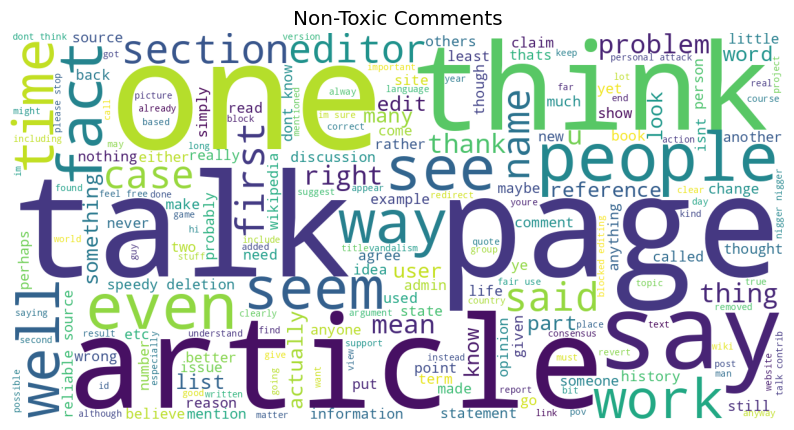

In [ ]:
# Overall Word Cloud

text = " ".join(df['clean_text'])
wc = WordCloud( width=1200, height=600, background_color='white').generate(text)
plt.figure(figsize=(10,6))
plt.imshow(wc)
plt.axis('off')
plt.title("Non-Toxic Comments")
plt.show()

**Inference**

Highlights the most frequent words across all comments.
    
Useful for identifying common discussion topics.

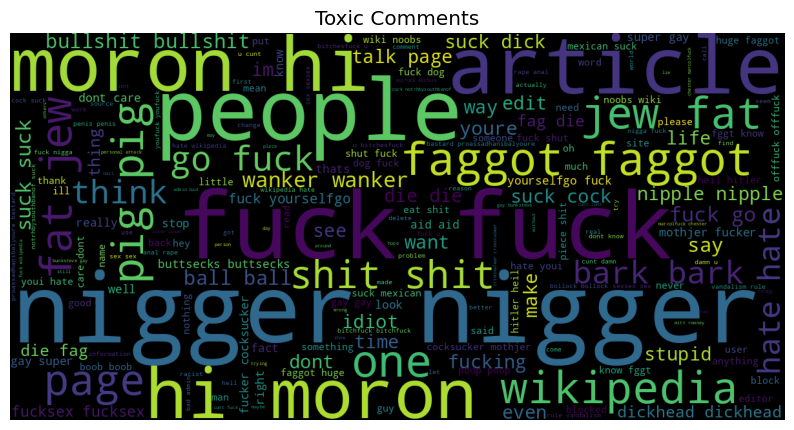

In [ ]:
#Toxic Comments Word Cloud

toxic_text = " ".join(df[df['toxic']==1]['clean_text'])
wc = WordCloud( width=1200, height=600, background_color='black').generate(toxic_text)
plt.figure(figsize=(10,6))
plt.imshow(wc)
plt.axis('off')
plt.title("Toxic Comments")
plt.show()


**Inference**
  
Reveals commonly occurring words in toxic comments.
    
Provides insights into abusive language patterns.

***Most Frequent Words***

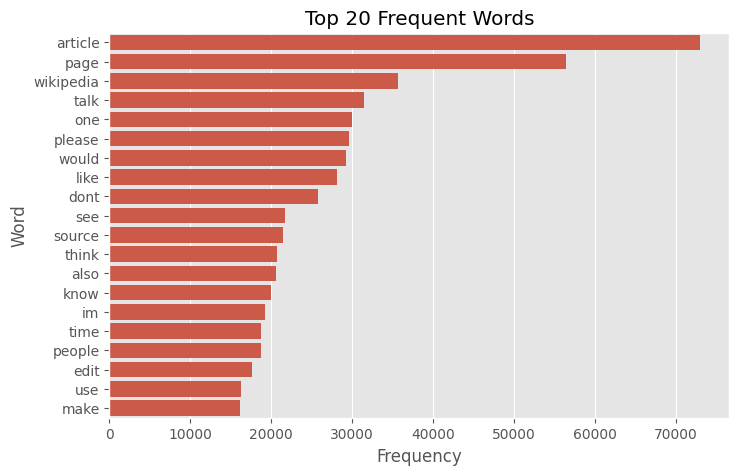

In [ ]:
# Top 20 Words

from collections import Counter
words = " ".join(df['clean_text']).split()
counter = Counter(words)
top20 = counter.most_common(20)
top_df = pd.DataFrame(top20, columns=['Word','Frequency'])
plt.figure(figsize=(8,5))
sns.barplot( x='Frequency', y='Word', data=top_df)
plt.title("Top 20 Frequent Words")
plt.show()

***N-Gram Analysis***

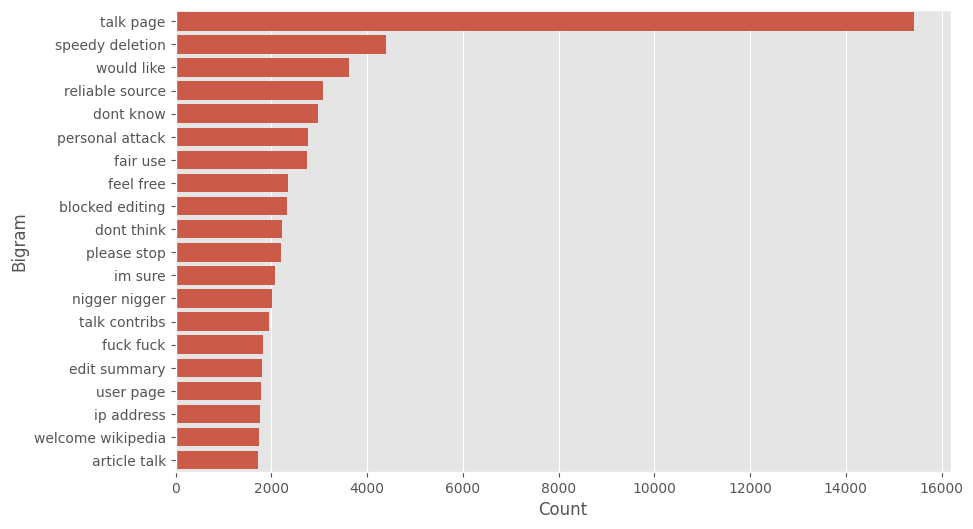

In [ ]:
# Top Bigrams

from sklearn.feature_extraction.text import CountVectorizer
vec = CountVectorizer(ngram_range=(2,2), max_features=20)
X = vec.fit_transform(df['clean_text'])
sum_words = X.sum(axis=0)

freq = [
    (word,
     sum_words[0,idx])
    for word,
    idx in vec.vocabulary_.items()
]

bigram = pd.DataFrame(freq, columns=['Bigram', 'Count'])
bigram = bigram.sort_values( by='Count', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot( x='Count', y='Bigram', data=bigram)
plt.show()


**Inference**

Frequently occurring phrases provide context beyond individual words.
    
Useful for identifying common abusive or conversational expressions.

**Business Insights**
1. The dataset is dominated by safe comments, with toxic categories representing a minority.
2. There is a significant class imbalance, particularly for Threat and Identity Hate, which will require techniques such as class weighting or resampling during model training.
3. Toxic, Obscene, and Insult labels frequently co-occur, indicating related forms of harmful language.
4. Most comments are short, making TF-IDF and transformer-based models well-suited for this task.
5. Word clouds and n-gram analysis reveal recurring abusive terms and phrases that contribute to toxicity.
6. Engineered features like word count and character count show measurable differences between safe and toxic comments and can complement textual embeddings.
7. The insights from this analysis will guide feature extraction, model selection, and evaluation strategies in the next phase.

#**ML Models(ML Models.ipynb), BERT model(Bert.ipynb) and DistilBert model(DistilBert.ipynb) needs to be executed seperately as executing every model in file gives Timeout exception.**

#**Model Comparison**

In [ ]:

comparison_df = pd.read_excel(f"{PROJECT_DIR}/data/ModelComparison.xlsx")

comparison_df


,Rank,Model,Accuracy,Micro Precision,Micro Recall,Micro F1,Macro F1,Weighted F1,Hamming Loss,Jaccard Score,ROC-AUC
0,1,BERT,0.9132,0.7223,0.7637,0.7424,0.4754,0.7227,0.0194,0.0586,0.9875
1,2,Linear SVM,0.9208,0.8479,0.6021,0.7042,0.5411,0.6966,0.0186,0.0478,NaN
2,3,Logistic Regression,0.9201,0.8594,0.5748,0.6889,0.5128,0.6811,0.0190,0.0456,NaN
3,4,Naive Bayes,0.9133,0.8469,0.4949,0.6247,0.4272,0.6183,0.0218,0.0364,NaN
4,5,Random Forest,0.9014,0.9781,0.1333,0.2347,0.1258,0.2306,0.0319,0.0089,NaN


#**Charts on Model Comparison**

<Figure size 1000x600 with 0 Axes>

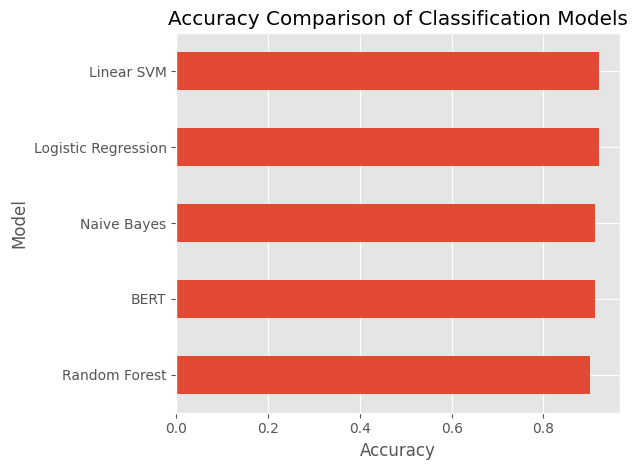

In [ ]:
# Accuracy Comparison - Shows the overall accuracy of each model.

plt.figure(figsize=(10,6))

comparison_df.sort_values("Accuracy").plot(
    x="Model",
    y="Accuracy",
    kind="barh",
    legend=False
)

plt.title("Accuracy Comparison of Classification Models")
plt.xlabel("Accuracy")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

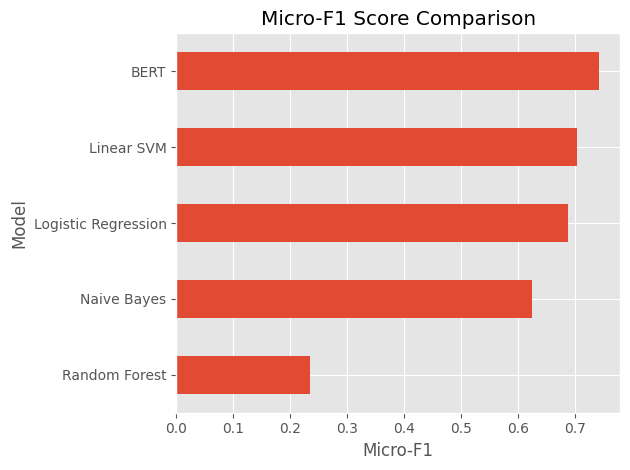

In [ ]:
# Micro-F1 Score Comparison (Most Important) - This is the primary metric for imbalanced multi-label classification.

plt.figure(figsize=(10,6))

comparison_df.sort_values("Micro F1").plot(
    x="Model",
    y="Micro F1",
    kind="barh",
    legend=False
)

plt.title("Micro-F1 Score Comparison")

plt.xlabel("Micro-F1")

plt.tight_layout()

plt.show()

<Figure size 1000x600 with 0 Axes>

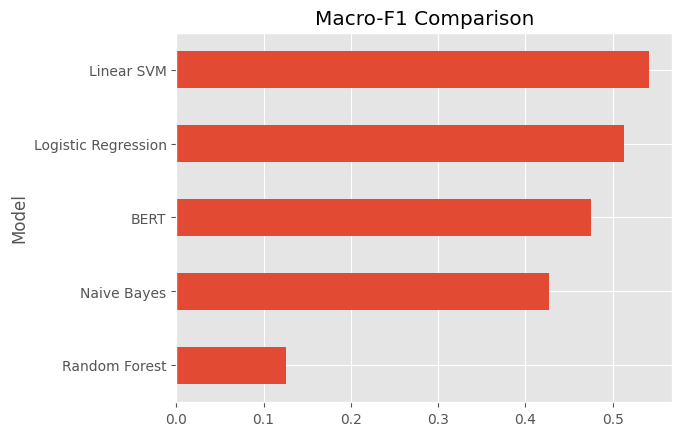

In [ ]:
# Macro-F1 Comparison

plt.figure(figsize=(10,6))

comparison_df.sort_values("Macro F1").plot(
    x="Model",
    y="Macro F1",
    kind="barh",
    legend=False
)

plt.title("Macro-F1 Comparison")

plt.show()

<Figure size 1000x600 with 0 Axes>

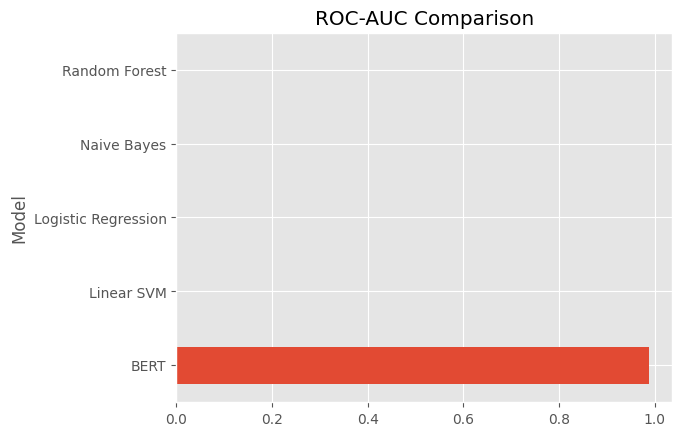

In [ ]:
# ROC-AUC Comparison

plt.figure(figsize=(10,6))

comparison_df.sort_values("ROC-AUC").plot(
    x="Model",
    y="ROC-AUC",
    kind="barh",
    legend=False
)

plt.title("ROC-AUC Comparison")

plt.show()

<Figure size 1000x600 with 0 Axes>

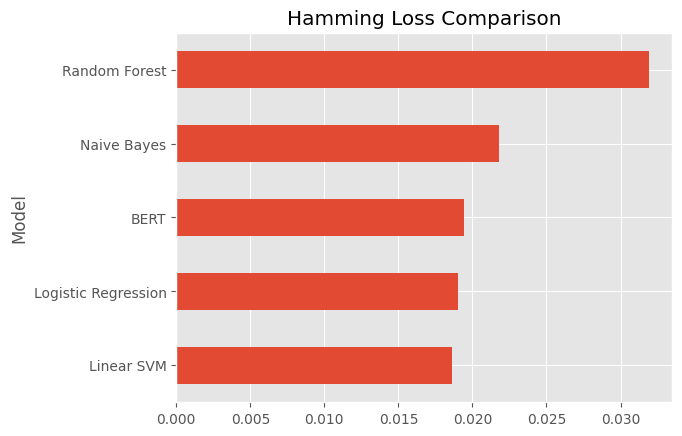

In [ ]:
# Hamming Loss Comparison (Lower is Better)

plt.figure(figsize=(10,6))

comparison_df.sort_values("Hamming Loss").plot(
    x="Model",
    y="Hamming Loss",
    kind="barh",
    legend=False
)

plt.title("Hamming Loss Comparison")

plt.show()

<Figure size 1000x600 with 0 Axes>

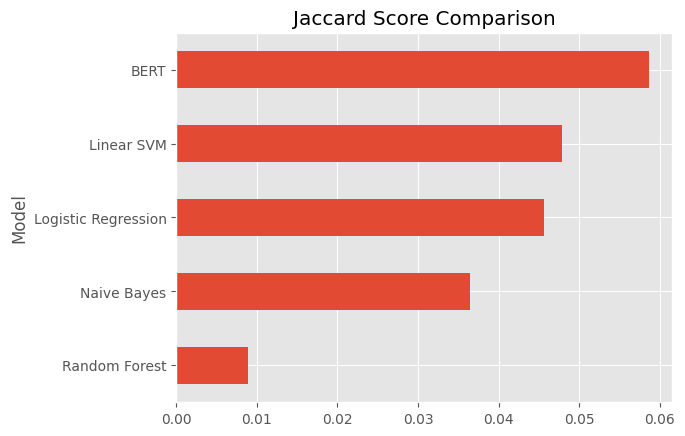

In [ ]:
# Jaccard Score Comparison

plt.figure(figsize=(10,6))

comparison_df.sort_values("Jaccard Score").plot(
    x="Model",
    y="Jaccard Score",
    kind="barh",
    legend=False
)

plt.title("Jaccard Score Comparison")

plt.show()

In [ ]:
comparison_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             5 non-null      int64  
 1   Model            5 non-null      object 
 2   Accuracy         5 non-null      float64
 3   Micro Precision  5 non-null      float64
 4   Micro Recall     5 non-null      float64
 5   Micro F1         5 non-null      float64
 6   Macro F1         5 non-null      float64
 7   Weighted F1      5 non-null      float64
 8   Hamming Loss     5 non-null      float64
 9   Jaccard Score    5 non-null      float64
 10  ROC-AUC          1 non-null      float64
dtypes: float64(9), int64(1), object(1)
memory usage: 572.0+ bytes


In [ ]:
# # Training Time Comparison

# plt.figure(figsize=(10,6))

# comparison_df.sort_values("Training Time (sec)").plot(
#     x="Model",
#     y="Training Time (sec)",
#     kind="barh",
#     legend=False
# )

# plt.title("Training Time Comparison")

# plt.xlabel("Seconds")

# plt.show()

In [ ]:
# # Prediction Time Comparison

# plt.figure(figsize=(10,6))

# comparison_df.sort_values("Prediction Time (sec)").plot(
#     x="Model",
#     y="Prediction Time (sec)",
#     kind="barh",
#     legend=False
# )

# plt.title("Prediction Time Comparison")

# plt.xlabel("Seconds")

# plt.show()

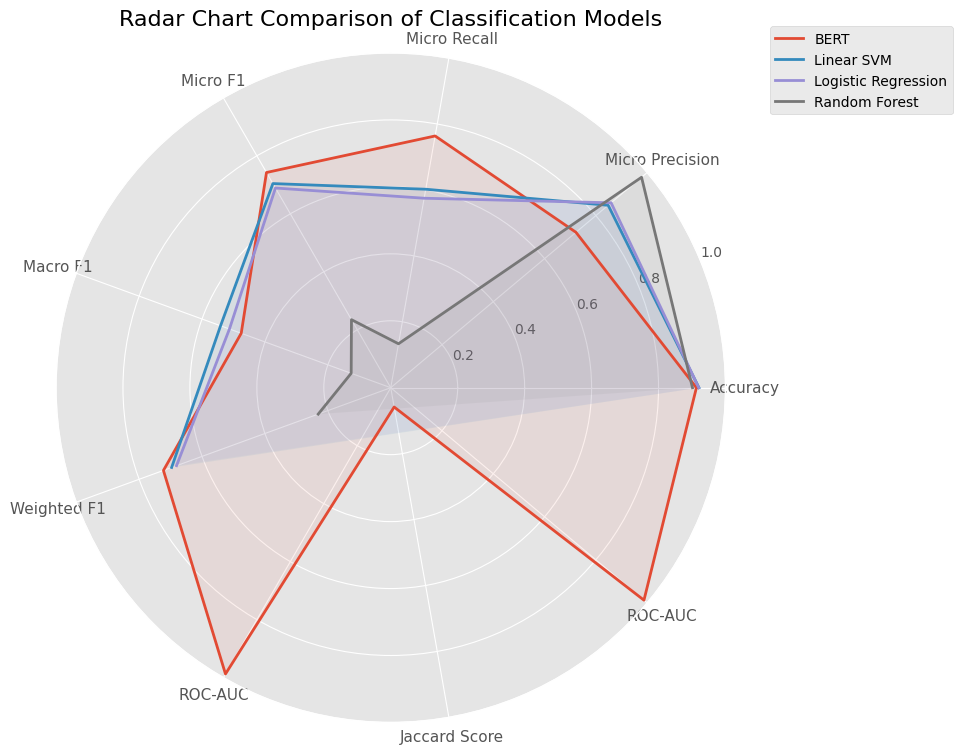

In [ ]:
# Radar Chart (Overall Performance of classic Machine Learning Models) - This combines multiple metrics into one visualization.

metrics = [
    "Accuracy",
    "Micro Precision",
    "Micro Recall",
    "Micro F1",
    "Macro F1",
    "Weighted F1",
    "ROC-AUC",
    "Jaccard Score",
    "ROC-AUC"
]

ml_models = comparison_df[
    comparison_df["Model"].isin([
        "Logistic Regression",
        "Naïve Bayes",
        "Linear SVM",
        "Random Forest",
        "BERT",
        "DistilBERT"
    ])
]

N = len(metrics)

# Angle for each axis
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()

# Close the circle
angles += angles[:1]

# Create figure
plt.figure(figsize=(10,10))

ax = plt.subplot(111, polar=True)

# Plot each model
for _, row in ml_models.iterrows():

    values = row[metrics].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Model"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.08
    )

# Labels
ax.set_xticks(angles[:-1])

ax.set_xticklabels(metrics, fontsize=11)

ax.set_ylim(0,1)

plt.title(
    "Radar Chart Comparison of Classification Models",
    fontsize=16,
    pad=20
)

plt.legend(
    bbox_to_anchor=(1.35,1.05)
)

plt.tight_layout()

plt.show()

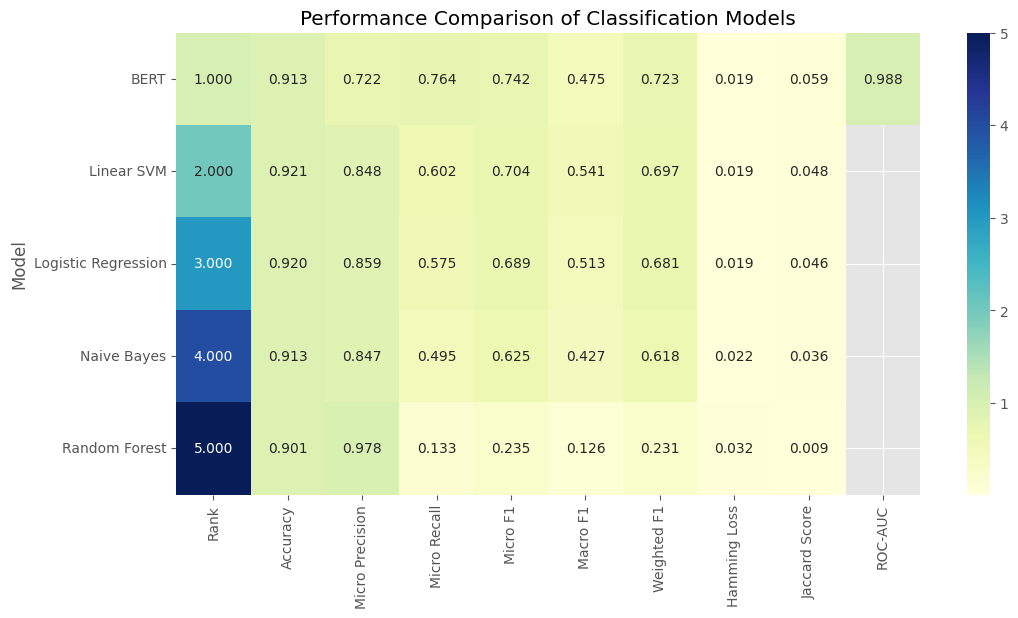

In [ ]:
# Heatmap of Model Performance

model_metrics = comparison_df.set_index("Model")

plt.figure(figsize=(12,6))

sns.heatmap(
    model_metrics,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("Performance Comparison of Classification Models")

plt.show()